In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from src.data_preprocessing import (
    read_oscilloscope_data, 
    segment_signal,
    perform_fft_on_segments,
    plot_random_segments,
    plot_manual_fft_as_full_spectrogram,
    plot_full_scipy_spectrogram,
    plot_spectrogram_samples,
    spectrogram_samples_from_file,
    spectrogram_samples_manual,
    spectrogram_samples_using_scipy,
    numpy_to_pillow,
    scipy_to_pillow
)

Считаем сигнал из файла.

In [3]:
df = read_oscilloscope_data(
    file_path='../data/raw/0702 без перекосов фаза A.txt',
    output_path='../data/processed/Anomalous.csv'
    )

healthy_signal = df['Data'].to_numpy()
healthy_signal_mean = np.mean(healthy_signal)
healthy_signal -= healthy_signal_mean

Отрисуем часть сигнала.

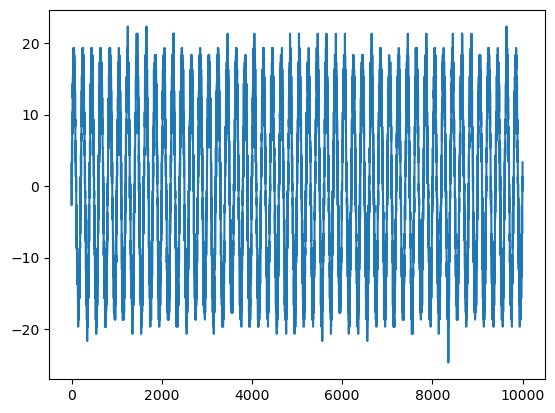

In [4]:
n = 10000
plt.plot(list(range(n)), healthy_signal[:n])
plt.show()

In [5]:
segments = segment_signal(healthy_signal, segment_length=10000, step=20, apply_window='blackman')

Случайные сегменты сигнала после применения оконной функции.

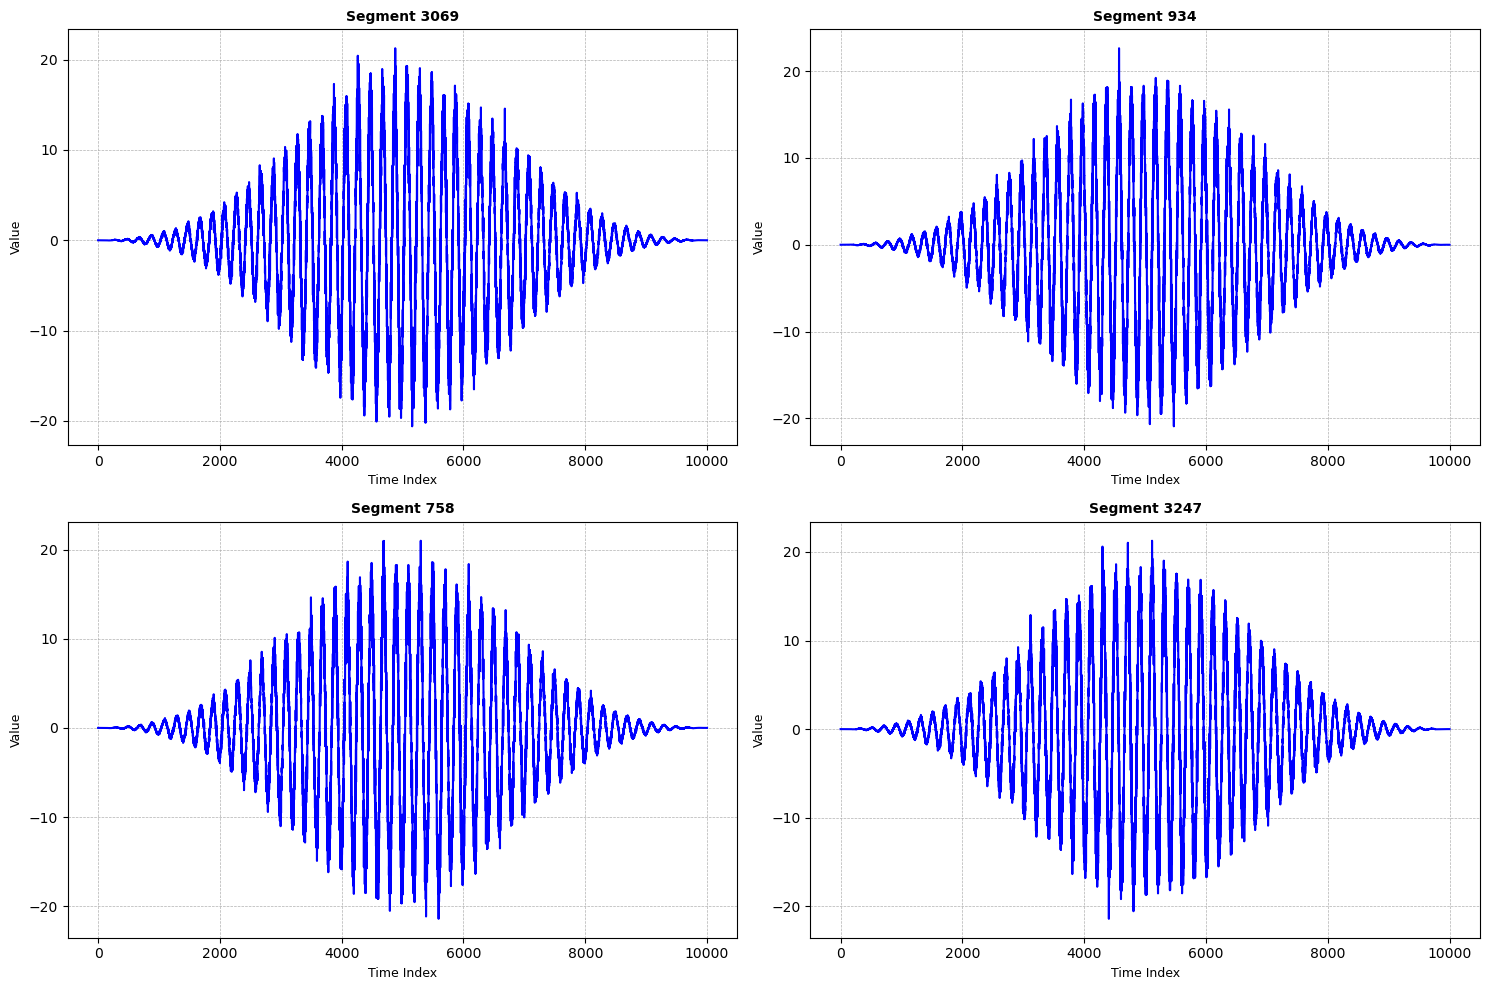

In [6]:
plot_random_segments(segments, num_segments=4, max_points=None, axis_labels=('Time Index', 'Value'))
plt.show()

In [7]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

In [8]:
def plot_single_segment_with_uncertainty(fft_segments, x_values=None, max_points=1000, n_std=2, title="Spectrum with Uncertainty",
                                         axis_labels=None, highlight_freqs=None, method='closest'):
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std 

    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = signal.resample(spectrum_mean, max_points)
        spectrum_std = signal.resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = signal.resample(x_values, max_points)
            else:
                x_values = signal.resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )

    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    
    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return fig, ax

Усредненный спектр.

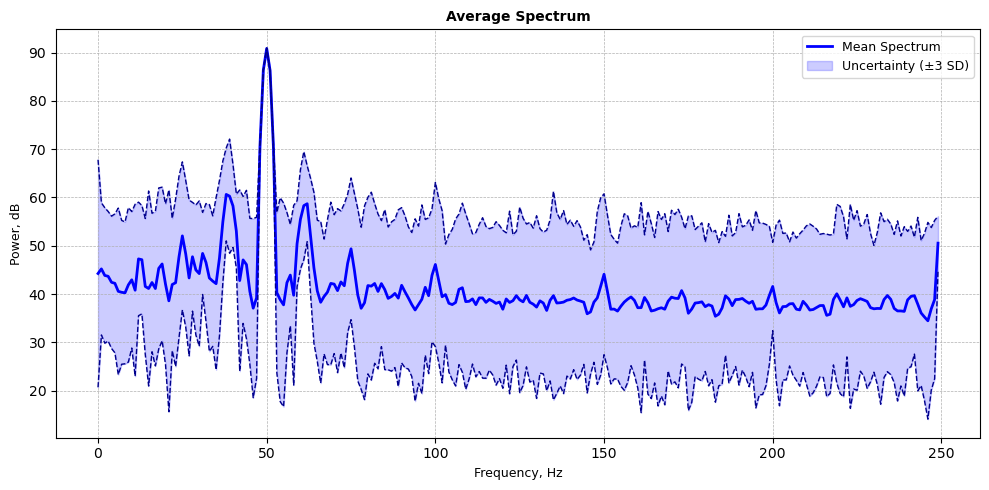

In [9]:
plot_single_segment_with_uncertainty(fft_segments, x_values=freqs, n_std=3, title='Average Spectrum')
plt.show()

Преобразуем полученные FFT-сегменты в спектрограмму.

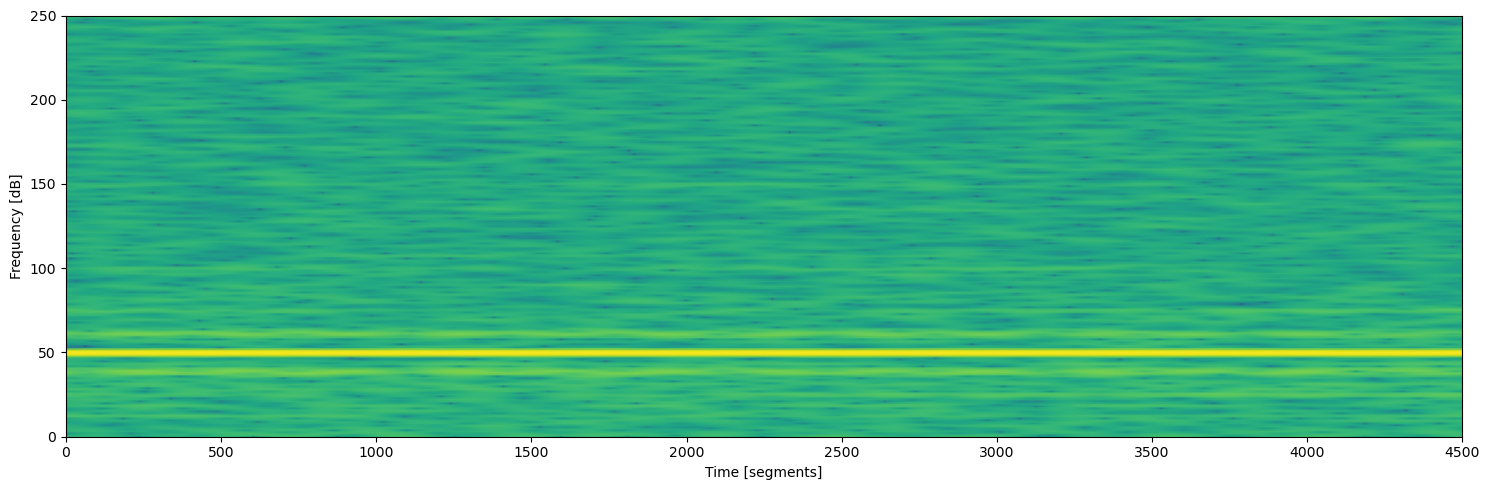

In [10]:
plot_manual_fft_as_full_spectrogram(fft_segments, freqs)

Сравним со спектрограммой, полученной при помощи scipy.signal.spectrogram.

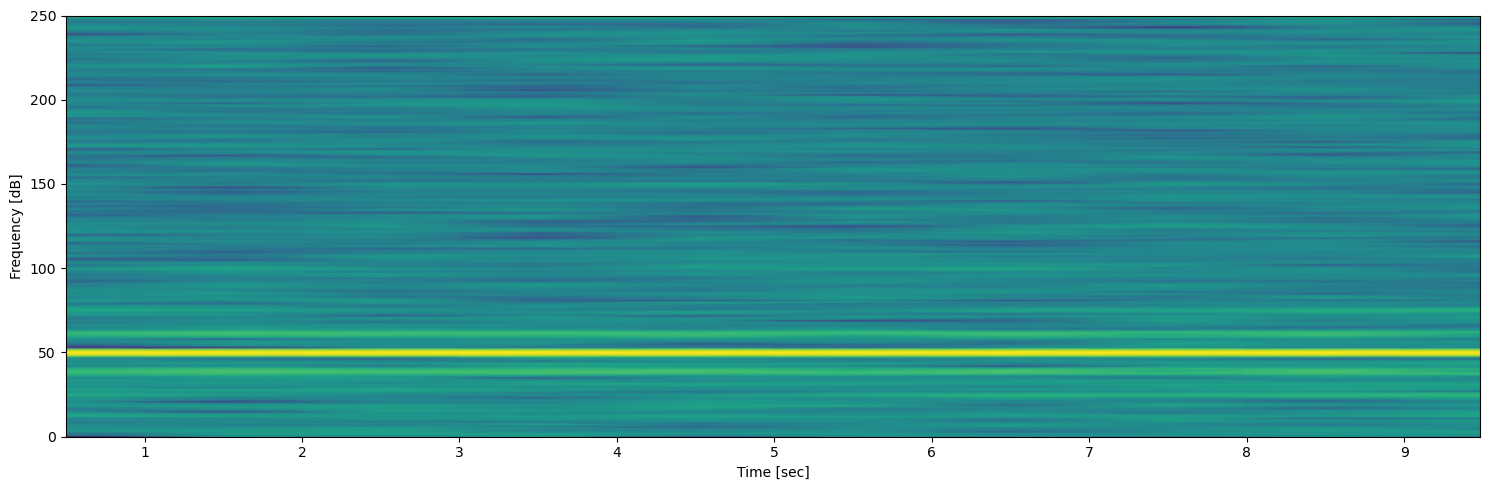

In [11]:
plot_full_scipy_spectrogram(healthy_signal)

Спектрограммы случайных сегментов сигнала заданной длины.

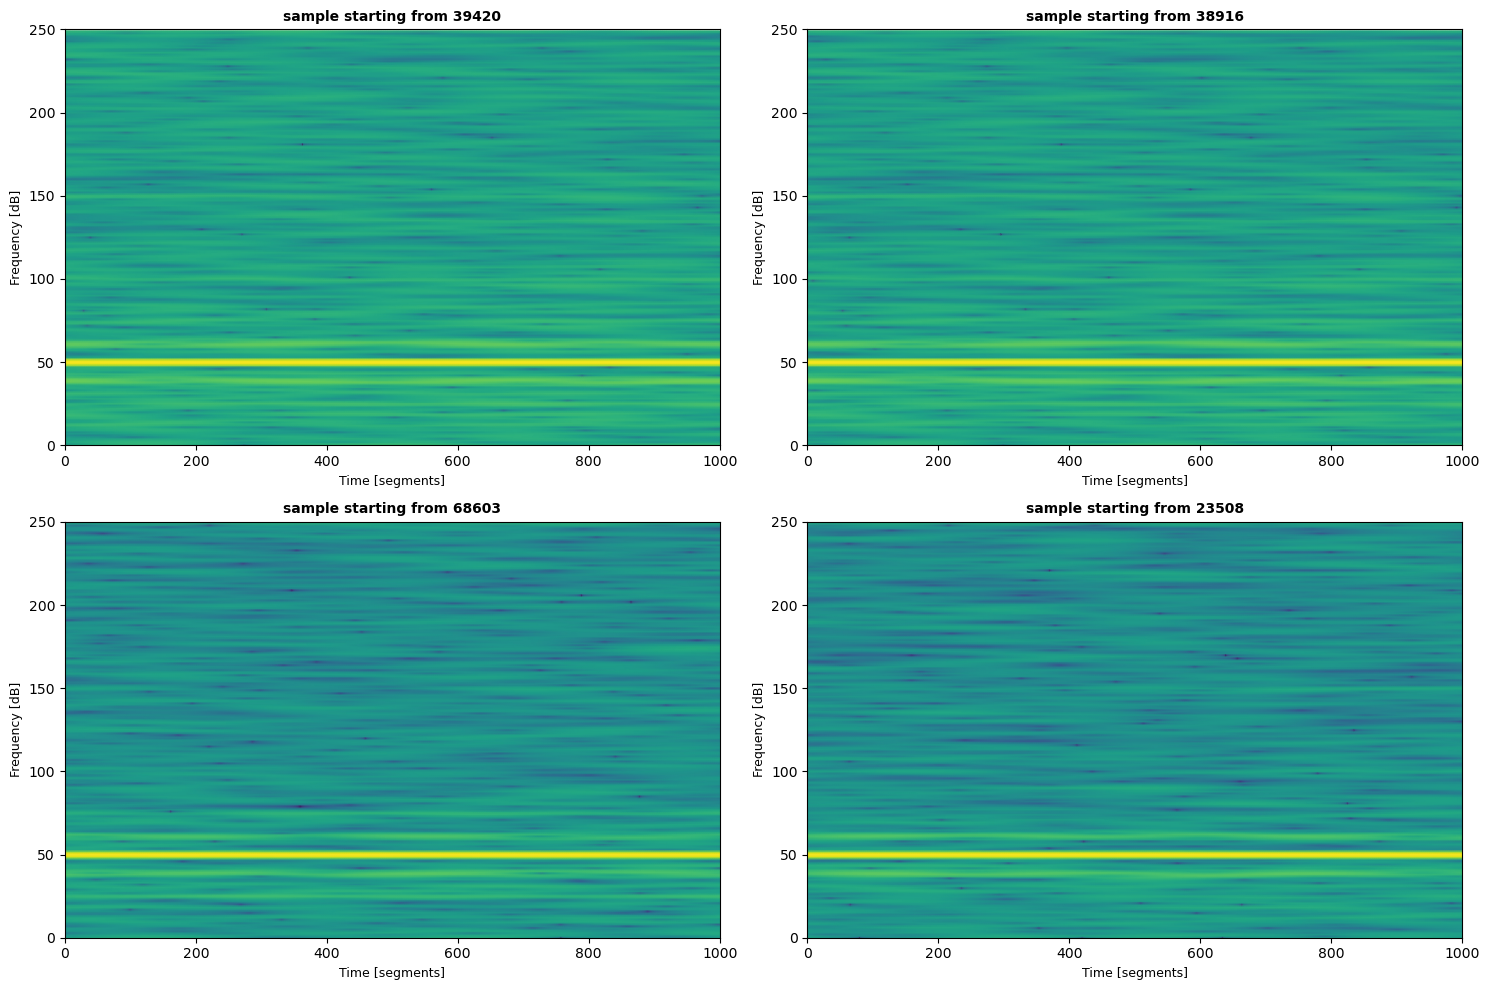

In [12]:
signal_samples = spectrogram_samples_manual(healthy_signal, 3, 4)
plot_spectrogram_samples(signal_samples, ('Time [segments]', 'Frequency [dB]'))
plt.show()

Считаем еще один сигнал из файла.

In [13]:
df = read_oscilloscope_data(
    file_path='../data/raw/0702  межвитковые фазы A ток фазы А.txt',
    output_path='../data/processed/Anomalous.csv'
    )

fault_signal = df['Data'].to_numpy()
fault_signal_mean = np.mean(fault_signal)
fault_signal -= fault_signal_mean

In [14]:
segments = segment_signal(fault_signal, segment_length=10000, step=20, apply_window='blackman')

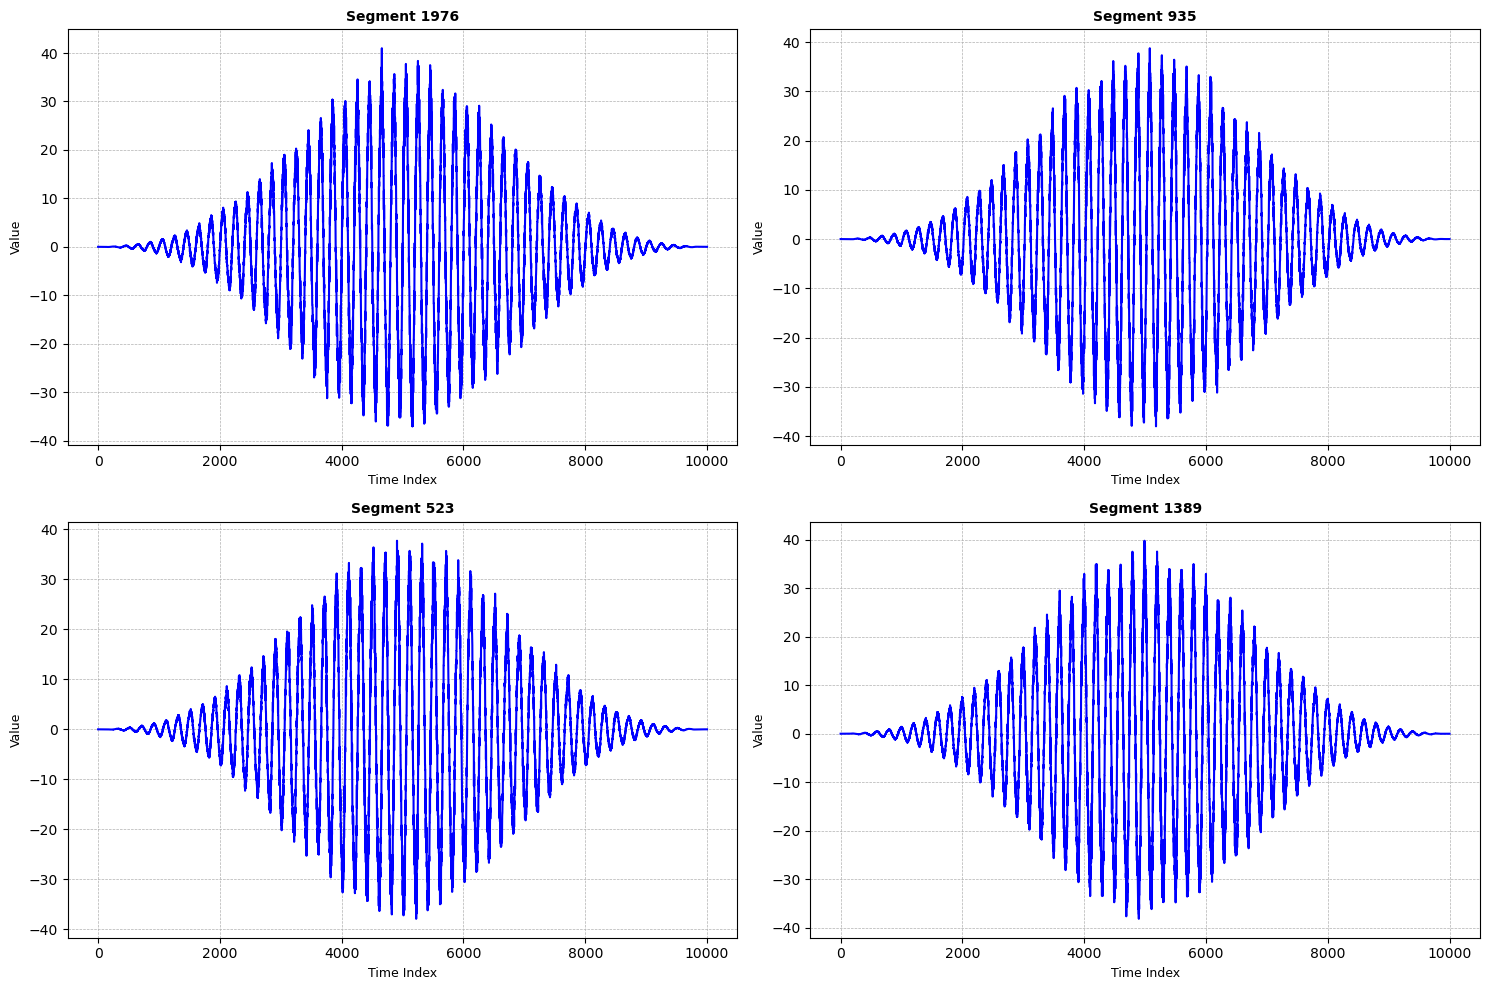

In [15]:
plot_random_segments(segments, num_segments=4, max_points=None, axis_labels=('Time Index', 'Value'))
plt.show()

In [16]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

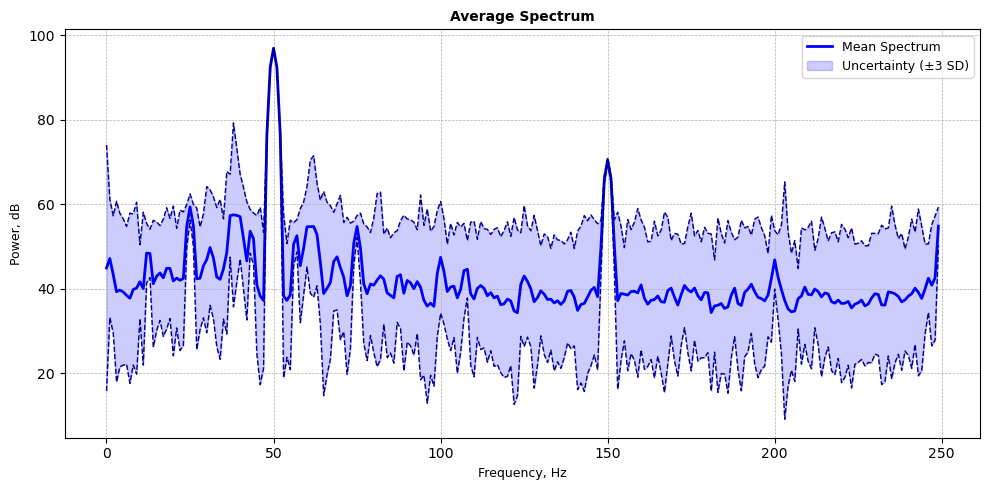

In [17]:
plot_single_segment_with_uncertainty(fft_segments, x_values=freqs, n_std=3, title='Average Spectrum')
plt.show()

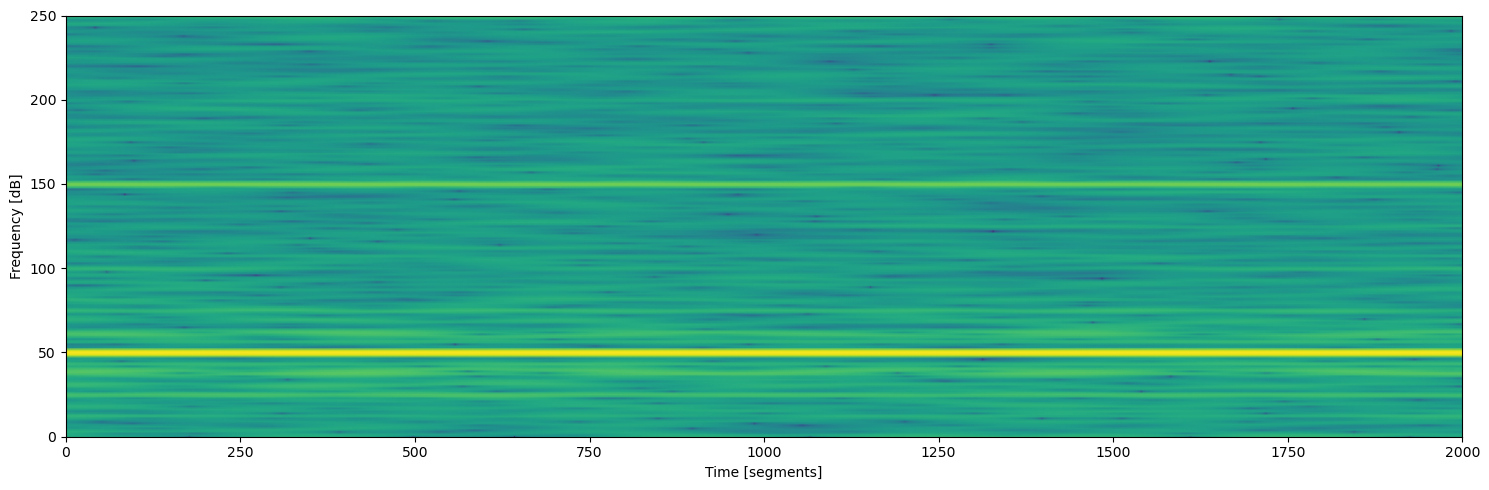

In [18]:
plot_manual_fft_as_full_spectrogram(fft_segments, freqs)

Функции сохранения спектрограммы в качестве картинки.

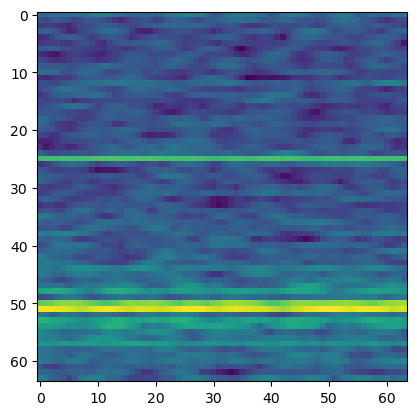

In [19]:
img = numpy_to_pillow(fft_segments.T)
plt.imshow(img)

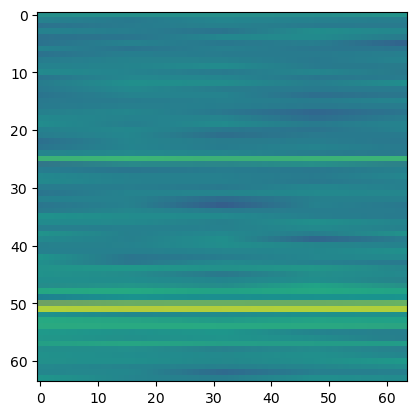

In [20]:
f, t, Sxx = signal.spectrogram(fault_signal, fs=10000, nperseg=10000, window='blackman', noverlap=20)
img = scipy_to_pillow(f, t, Sxx)
plt.imshow(img, cmap='gray')

Набираем датасет:

In [21]:
from pathlib import Path
import os
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import blackman
import shutil


if os.path.isdir('../data/processed'):
    shutil.rmtree('../data/processed')
os.makedirs('../data/processed')
for input_file in Path('../data/raw').rglob('*.txt'):
    df = read_oscilloscope_data(
        file_path=input_file,
        output_path='../data/processed/Anomalous.csv'
    )
    some_signal = df['Data'].to_numpy()
    some_signal_mean = np.mean(some_signal)
    some_signal -= some_signal_mean
    segments = segment_signal(some_signal, segment_length=10000, step=20, apply_window='blackman')
    fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)
    os.makedirs(f"../data/processed/{input_file.name}/ours_FFT")
    os.makedirs(f"../data/processed/{input_file.name}/ours_spectrogram")
    for idx in range(len(fft_segments)):
        np.save(f"../data/processed/{input_file.name}/ours_FFT/{idx}.npy", fft_segments[idx])
    #np.save(f"../data/processed/{input_file.name}/ours_FFT/freqs.npy", freqs)
    signal_samples = spectrogram_samples_manual(some_signal, 3, 5000)
    signal_samples += spectrogram_samples_manual(some_signal, 3, 5000)
    #np.save(f"../data/processed/{input_file.name}/ours_spectrogram/freqs.npy", signal_samples[0][1])
    #np.save(f"../data/processed/{input_file.name}/ours_spectrogram/T.npy", signal_samples[0][2])
    for idx in range(len(signal_samples)):
        np.save(f"../data/processed/{input_file.name}/ours_spectrogram/{idx}_FFT.npy", signal_samples[idx][3])

KeyboardInterrupt: 

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class FFTDataset(Dataset):
    def __init__(self, files, labels):
        self.data = []
        self.labels = []
        for filepath in files:
            self.data.append(torch.FloatTensor(np.load(filepath)).unsqueeze(0))
        self.labels = labels

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index], self.labels[index]

In [ ]:
from sklearn.model_selection import train_test_split
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


healthy_fft = list(Path('../data/processed/0702 без перекосов фаза A.txt/ours_FFT').rglob('*.npy'))
healthy_labels = [1 for _ in range(len(healthy_fft))]
fault_fft = list(Path('../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_FFT').rglob('*.npy'))
fault_labels = [0 for _ in range(len(fault_fft))]

fft_list = healthy_fft + fault_fft
labels_list = healthy_labels + fault_labels

Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=42, test_size=0.25)
Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=42, test_size=0.25)

In [ ]:
BATCH_SIZE = 32

train_dataset = FFTDataset(Xtrain, ytrain)
val_dataset = FFTDataset(Xval, yval)
test_dataset = FFTDataset(Xtest, ytest)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class ResNet1dLayer(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size_1, kernel_size_2, padding=0, stride=1):
        super().__init__()
        self.input = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=in_channels, 
                            out_channels=in_channels, 
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm1d(in_channels),
            torch.nn.ReLU(),
            torch.nn.Conv1d(in_channels=in_channels, 
                            out_channels=out_channels, 
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm1d(out_channels),                
        )
        self.residual = torch.nn.Sequential(
            torch.nn.Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size_2,
                padding=padding,
                stride=stride
            )
        )
        self.activation = torch.nn.ReLU() 

    def forward(self, x):
        return self.activation(self.input(x) + self.residual(x))


class ResNet1d(torch.nn.Module):
    def __init__(self, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=1, 
                            out_channels=1, 
                            kernel_size=7, 
                            stride=2),
            torch.nn.BatchNorm1d(1),
            torch.nn.MaxPool1d(kernel_size=3),
            ResNet1dLayer(in_channels=1, out_channels=1, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=1, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=2, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=2, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=4, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=4, out_channels=8, kernel_size_1=3, kernel_size_2=5),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(in_features=8, out_features=out_features),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(self.seq(x).squeeze()).squeeze()

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

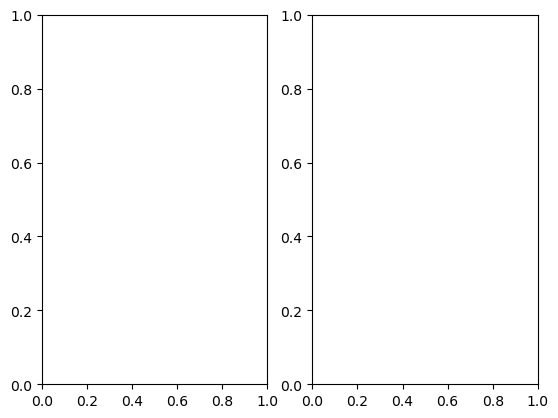

In [ ]:
import IPython
import IPython.display
from sklearn.metrics import f1_score


EPOCHS = 10
resnet_1d = ResNet1d()
optimizer = torch.optim.Adam(resnet_1d.parameters())
criterion = torch.nn.BCELoss()


def train(model, train_loader, val_loader, epochs, criterion, optimizer, metric, filename, mode='binary', average='binary'):
    best_val_metric = np.inf
    epoch_train = []
    epoch_val = []
    epoch_metric = []
    for epoch in range(epochs):
        model.train()
        train_loss = []
        val_loss = []
        val_metric = []
        for x, y in train_loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y.to(dtype=torch.float))
            train_loss.append(loss.item())
            loss.backward() 
            optimizer.step()
    epoch_train.append(sum(train_loss) / len(train_loader))
    model.eval()
    with torch.no_grad():
        for x, y in val_loader:
            out = model(x)
            loss = criterion(out, y.to(dtype=torch.float))
            val_loss.append(loss.item())
            if mode == 'binary':
                val_metric.append(metric(y, out > 0.5, average=average))
            else:
                val_metric.append(metric(y, torch.argmax(out, dim=1), average=average))
    mean_val_metric = sum(val_metric) / len(val_loader)
    if mean_val_metric < best_val_metric:
        torch.save(model.state_dict(), filename)
    epoch_val.append(sum(val_loss) / len(val_loader))
    epoch_metric.append(mean_val_metric)
    IPython.display.clear_output()
    fig, ax = plt.subplots(nrows=1, ncols=2)
    ax[0].plot(list(range(0, epoch+1)), epoch_train, label='train')
    ax[0].plot(list(range(0, epoch+1)), epoch_val, label='val')
    ax[0].set_legend()
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[1].plot(list(range(0, epoch+1)), epoch_metric)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Metric')
    plt.show()


train(resnet_1d, train_loader, val_loader, EPOCHS, criterion, optimizer, f1_score, 'best_1d.pt')

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


best_resnet_1d = ResNet1d()
best_resnet_1d.load_state_dict(torch.load('best_1d.pt'))


def mean_metric_on_test(model, metric, test_loader, mode='binary', average='binary'):
    metrics = []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            if mode == 'binary':
                metrics.append(metric(y, out > 0.5, average=average))
            else:
                metrics.append(metric(y, torch.argmax(out, dim=1), average=average))
    return sum(metrics) / len(test_loader)


def get_confusion_matrix(model, test_loader, mode='binary'):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            y_true += y.tolist()
            out = model(x)
            if mode == 'binary':
                y_pred += (out > 0.5).tolist()
            else:
                y_pred += torch.argmax(out, dim=1).tolist()
    sns.heatmap(confusion_matrix(y_true, y_pred))
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.title('Матрица ошибок')
    plt.show()


print(f'F1 = {mean_metric_on_test(best_resnet_1d, f1_score, test_loader)}')
get_confusion_matrix(best_resnet_1d, test_loader)

1.0

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

healthy_fft = list(Path('../data/processed/0702 без перекосов фаза A.txt/ours_spectrogram').rglob('*.npy'))
healthy_labels = [1 for _ in range(len(healthy_fft))]
fault_fft = list(Path('../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram').rglob('*.npy'))
fault_labels = [0 for _ in range(len(fault_fft))]
fft_list = healthy_fft + fault_fft
labels_list = healthy_labels + fault_labels

Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=42, test_size=0.25)
Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=42, test_size=0.25)

In [ ]:
train_dataset = FFTDataset(Xtrain, ytrain)
val_dataset = FFTDataset(Xval, yval)
test_dataset = FFTDataset(Xtest, ytest)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class ResNet2dLayer(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size_1, kernel_size_2, padding=0, stride=1):
        super().__init__()
        self.input = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels, 
                            out_channels=in_channels, 
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(in_channels),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=in_channels, 
                            out_channels=out_channels, 
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(out_channels),                
        )
        self.residual = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size_2,
                padding=padding,
                stride=stride
            )
        )
        self.activation = torch.nn.ReLU() 

    def forward(self, x):
        return self.activation(self.input(x) + self.residual(x))


class ResNet2d(torch.nn.Module):
    def __init__(self, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, 
                            out_channels=1, 
                            kernel_size=7, 
                            stride=2),
            torch.nn.BatchNorm2d(1),
            torch.nn.MaxPool2d(kernel_size=3),
            ResNet2dLayer(in_channels=1, out_channels=1, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=1, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=2, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=2, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=4, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=4, out_channels=8, kernel_size_1=3, kernel_size_2=5),
            torch.nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(in_features=8, out_features=out_features),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(self.seq(x).squeeze()).squeeze()

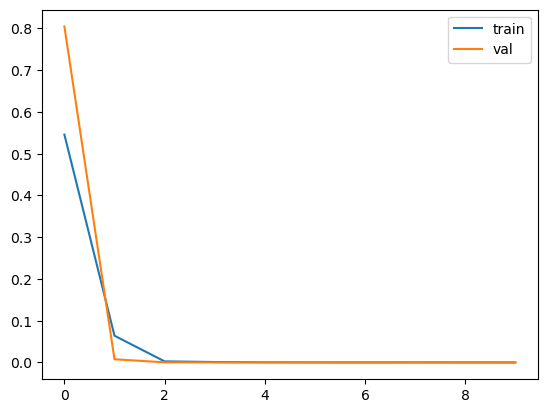

In [ ]:
EPOCHS = 10
resnet_2d = ResNet2d()
optimizer = torch.optim.Adam(resnet_2d.parameters())
criterion = torch.nn.BCELoss()

train(resnet_2d, train_loader, val_loader, EPOCHS, criterion, optimizer, f1_score, 'best_2d.pt')

In [ ]:
best_resnet_2d = ResNet2d()
best_resnet_2d.load_state_dict(torch.load('best_2d.pt'))

print(f'F1 = {mean_metric_on_test(best_resnet_1d, f1_score, test_loader)}')
get_confusion_matrix(best_resnet_1d, test_loader)

1.0

Попробуем многоклассовую классификацию.

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

healthy_fft = list(Path('../data/processed/0702 без перекосов фаза A.txt/ours_FFT').rglob('*.npy'))
healthy_labels = [0 for _ in range(len(healthy_fft))]
phase_fft = list(Path('../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_FFT').rglob('*.npy'))
phase_labels = [1 for _ in range(len(phase_fft))]
disbalance_fft = list(Path('../data/processed/21 02 дисбаланс макс обороты 100%.txt/ours_FFT').rglob('*.npy'))
disbalance_labels = [2 for _ in range(len(disbalance_fft))]

fft_list = healthy_fft + phase_fft + disbalance_fft
labels_list = healthy_labels + phase_labels + disbalance_labels

Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=42, test_size=0.25)
Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=42, test_size=0.25)

train_dataset = FFTDataset(Xtrain, ytrain)
val_dataset = FFTDataset(Xval, yval)
test_dataset = FFTDataset(Xtest, ytest)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

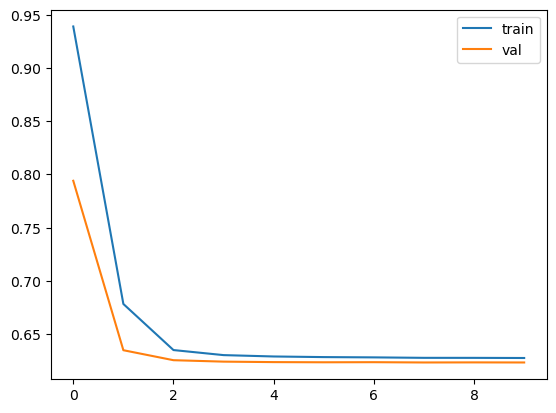

In [ ]:
EPOCHS = 10
resnet_1d = ResNet1d(out_features=3)
optimizer = torch.optim.Adam(resnet_1d.parameters())
criterion = torch.nn.CrossEntropyLoss()

train(resnet_1d, train_loader, val_loader, EPOCHS, criterion, optimizer, f1_score, 'best_1d_multiclass.pt', mode='multi', average='micro')

In [ ]:
best_resnet_1d = ResNet1d(out_features=3)
best_resnet_1d.load_state_dict(torch.load('best_1d_multiclass.pt'))

print(f'F1 = {mean_metric_on_test(best_resnet_1d, f1_score, test_loader, mode='multi', average='micro')}')
get_confusion_matrix(best_resnet_1d, test_loader, mode='multi')

0.7782515991471216

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

healthy_fft = list(Path('../data/processed/0702 без перекосов фаза A.txt/ours_spectrogram').rglob('*.npy'))
healthy_labels = [0 for _ in range(len(healthy_fft))]
phase_fft = list(Path('../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram').rglob('*.npy'))
phase_labels = [1 for _ in range(len(phase_fft))]
disbalance_fft = list(Path('../data/processed/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram').rglob('*.npy'))
disbalance_labels = [2 for _ in range(len(disbalance_fft))]

fft_list = healthy_fft + phase_fft + disbalance_fft
labels_list = healthy_labels + phase_labels + disbalance_labels

Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=42, test_size=0.25)
Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=42, test_size=0.25)

train_dataset = FFTDataset(Xtrain, ytrain)
val_dataset = FFTDataset(Xval, yval)
test_dataset = FFTDataset(Xtest, ytest)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

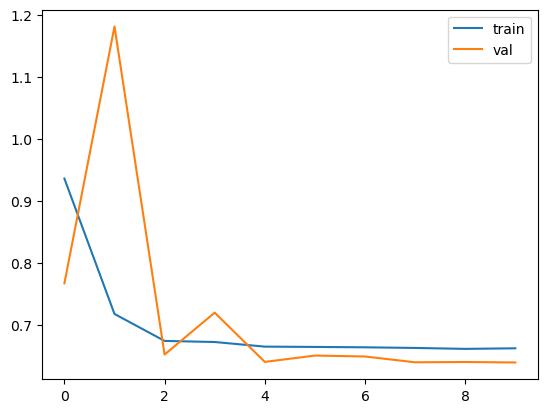

In [ ]:
EPOCHS = 10
resnet_2d = ResNet2d(out_features=3)
optimizer = torch.optim.Adam(resnet_2d.parameters())
criterion = torch.nn.CrossEntropyLoss()

train(resnet_2d, train_loader, val_loader, EPOCHS, criterion, optimizer, f1_score, 'best_2d_multiclass.pt', mode='multi', average='micro')

In [ ]:
best_resnet_2d = ResNet2d(out_features=3)
best_resnet_2d.load_state_dict(torch.load('best_2d_multiclass.pt'))

print(f'F1 = {mean_metric_on_test(best_resnet_2d, f1_score, test_loader, mode='multi', average='micro')}')
get_confusion_matrix(best_resnet_2d, test_loader)

0.6674107142857143